# TechNova - Spam Detection (Advanced Pipeline)
### COS30049 - Computing Technology Innovation Project - Assignment 2

---

## Project Overview
This notebook presents a comprehensive Machine Learning pipeline for **Spam Detection**.
The pipeline is designed to meet strict robustness and evaluation criteria, integrating both text feature extraction and metadata analysis.

### Features & ML Types Included:
1. **Core ML (Classification):** TF-IDF + 4 Models (Naive Bayes, SVM, Logistic Regression, Random Forest).
2. **Additional ML 1 (Unsupervised K-Means):** Topic clustering of Spam campaigns.
3. **Additional ML 2 (Metadata Pipeline):** Combining numerical metadata (length, time) with text features via `ColumnTransformer`.
4. **Additional Dataset:** Data Augmentation generating `synthetic_nlpaug.csv` for stress-testing model robustness.

---
## Section 0: Setup & Imports

In [ ]:
# Install required libraries if needed (uncomment to run)
# !pip install pandas numpy matplotlib seaborn scikit-learn nltk nlpaug 

import os
import re
import string
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# NLTK setup
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

---
## Section 1: Data Loading & Exploratory Data Analysis (EDA)

We load the primary dataset (`Spam-50k.csv`) along with the additional 220k dataset (`spam_Emails_data.csv`), standardize their schemas, and merge them for a total of ~270k rows to perform initial exploration.

In [ ]:
# Gọi module xử lý dữ liệu của nhóm
import sys
import os
if './src' not in sys.path: sys.path.append('./src') # Đảm bảo load module từ thư mục src

from data_preprocessing import load_combined_datasets, clean_dataframe

ORIGINAL_FILE = "Spam-50k.csv"
NEW_DATASET_FILE = "spam_Emails_data.csv"

# 1. Load và gộp 2 datasets (~270k rows)
df_raw = load_combined_datasets(ORIGINAL_FILE, NEW_DATASET_FILE)

# 2. Xóa NaNs và làm sạch sơ bộ
df = clean_dataframe(df_raw)

print(f"Dataset loaded and cleaned. Shape: {df.shape}")
df.head()

In [ ]:
# Distribution of Spam vs Ham
import sys
# Import visualization scripts from the 'viz' directory defined in our project structure
sys.path.append('./viz')
from viz_eda import plot_class_distribution, plot_text_length_distribution

# Plot pie and bar charts
plot_class_distribution(df)

In [ ]:
# Text length distribution
df['text_length'] = df['combined_text'].apply(lambda x: len(str(x)))
plot_text_length_distribution(df, text_col='combined_text')

---
## Section 2: Text Preprocessing

Cleaning the text data: lowercasing, placeholder replacement for URLs/emails/numbers, removing punctuation, and dropping stopwords.

In [ ]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "url_placeholder", text)
    text = re.sub(r"\S+@\S+", "email_placeholder", text)
    text = re.sub(r"\d+", "number_placeholder", text)
    text = re.sub(r'[^\w\s!$?\-€£]', '', text) # keep important characters
    
    tokens = word_tokenize(text)
    return " ".join([w for w in tokens if w not in stop_words and len(w) > 1])

print("Cleaning text (this may take a minute)...")
df["cleaned_text"] = df["combined_text"].apply(clean_text)

# Example comparison
print("- ORIGINAL:", df['combined_text'].iloc[0][:100], "...")
print("- CLEANED: ", df['cleaned_text'].iloc[0][:100], "...")

In [ ]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["label"] = le.fit_transform(df["Spam/Ham"])

print("Label Mapping:")
for cls, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {{cls}} -> {{encoded}}")

---
## Section 3: ML Type 1 - Core Text Classifiers

We train 4 core models using TF-IDF text features.
*   **Models:** Naive Bayes, Linear SVM, Logistic Regression, Random Forest
*   **Validation Split:** Train (70%), Validation (15%), Test (15%)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

X = df["cleaned_text"]
y = df["label"]

# 70% Train, 30% Temp -> 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training: {len(X_train)} | Validation: {len(X_val)} | Testing: {len(X_test)}")

In [ ]:
def get_tfidf():
    return TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1, 2), min_df=5, max_df=0.8)

core_models = {
    "Naive Bayes": Pipeline([("tfidf", get_tfidf()), ("clf", MultinomialNB())]),
    "SVM (LinearSVC)": Pipeline([("tfidf", get_tfidf()), ("clf", CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=10000)))]),
    "Logistic Regression": Pipeline([("tfidf", get_tfidf()), ("clf", LogisticRegression(random_state=42, max_iter=1000))]),
    "Random Forest": Pipeline([("tfidf", get_tfidf()), ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])
}

results = {}
for name, model in core_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='binary'),
        "Recall": recall_score(y_test, y_pred, average='binary'),
        "F1-Score": f1_score(y_test, y_pred, average='binary'),
        "y_pred": y_pred,
        "model": model
    }

In [ ]:
# Evaluate performance visually
from viz_model_comparison import plot_metrics_comparison, plot_roc_curves
from viz_confusion_matrices import plot_all_confusion_matrices

plot_metrics_comparison(results)

In [ ]:
plot_all_confusion_matrices(results, y_test, le)

In [ ]:
plot_roc_curves({name: res['model'] for name, res in results.items()}, X_test, y_test)

---
## Section 4: Cross-Validation & Hyperparameter Tuning

We perform 5-fold CV to ensure model stability, then tune the best model using `GridSearchCV` while leveraging a `PredefinedSplit` to avoid data leakage.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from viz_cross_validation import plot_cv_results

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in core_models.items():
    print(f"Running CV for {name}...")
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_results[name] = {"Mean F1": scores.mean(), "Std F1": scores.std()}

plot_cv_results(cv_results)

In [ ]:
# GridSearchCV on SVM (which generally performs very well and fast)
from sklearn.model_selection import PredefinedSplit, GridSearchCV

print("Tuning SVM (LinearSVC) model...")
svm_pipeline = Pipeline([("tfidf", get_tfidf()), ("clf", CalibratedClassifierCV(LinearSVC(random_state=42)))])

# Combine Train+Val, mark training as -1 and validation as 0
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])
test_fold = np.concatenate([np.full(len(X_train), -1), np.zeros(len(X_val))])
ps = PredefinedSplit(test_fold)

param_grid = {
    "clf__estimator__C": [0.1, 1.0, 10.0]
}

gs = GridSearchCV(estimator=svm_pipeline, param_grid=param_grid, cv=ps, scoring="f1", n_jobs=-1, verbose=1, refit=False)
gs.fit(X_train_val, y_train_val)

print("Best Parameters:", gs.best_params_)
print("Best Valid F1-Score:", gs.best_score_)

# Retrain tuned model on purely train set
tuned_svm = Pipeline([("tfidf", get_tfidf()), ("clf", CalibratedClassifierCV(LinearSVC(random_state=42, C=gs.best_params_['clf__estimator__C'])))])
tuned_svm.fit(X_train, y_train)

y_pred_tuned = tuned_svm.predict(X_test)
print("F1-Score on TEST SET after tuning:", f1_score(y_test, y_pred_tuned))

---
## Section 5: Additional ML Type 1 - Structural/Metadata Pipeline

Instead of just words, spam is often characterized by extreme text lengths, lots of special characters, or sending patterns (weekends).
We extract these features and build a `ColumnTransformer` pipeline.

In [ ]:
df["word_count"] = df['combined_text'].apply(lambda x: len(str(x).split()))
df["special_char_count"] = df['combined_text'].apply(lambda x: sum(1 for c in str(x) if c in string.punctuation))

# Simulate date features (often lost or corrupted in CSVs)
np.random.seed(42)
df["hour"] = np.random.choice([2, 3, 14, 15], size=len(df)) 
df["is_weekend"] = np.random.choice([0, 1], p=[0.7, 0.3], size=len(df))

# Features subset
FEATURES = ["cleaned_text", "text_length", "word_count", "special_char_count", "hour", "is_weekend"]
X_meta = df[FEATURES]
y_meta = df["label"]

X_train_m, X_temp_m, y_train_m, y_temp_m = train_test_split(X_meta, y_meta, test_size=0.3, random_state=42, stratify=y_meta)
X_val_m, X_test_m, y_val_m, y_test_m = train_test_split(X_temp_m, y_temp_m, test_size=0.5, random_state=42, stratify=y_temp_m)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

preprocessor = ColumnTransformer(transformers=[
    ("text", get_tfidf(), "cleaned_text"),
    ("num", MinMaxScaler(), ["text_length", "word_count", "special_char_count", "hour", "is_weekend"]),
])

meta_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)) # RF works well with numerical + sparse features
])

print("Training Metadata Pipeline (Random Forest)...")
meta_pipeline.fit(X_train_m, y_train_m)
y_pred_meta = meta_pipeline.predict(X_test_m)

print(f"Accuracy with Metadata: {accuracy_score(y_test_m, y_pred_meta):.4f}")
print(f"F1-Score with Metadata: {f1_score(y_test_m, y_pred_meta):.4f}")
print(classification_report(y_test_m, y_pred_meta, target_names=le.classes_))

---
## Section 6: Additional ML Type 2 - Unsupervised K-Means Clustering

To discover hidden patterns, we take ONLY spam emails and cluster them into 4 distinct groups using **K-Means**.

K-Means completed. Plotting PCA projection...


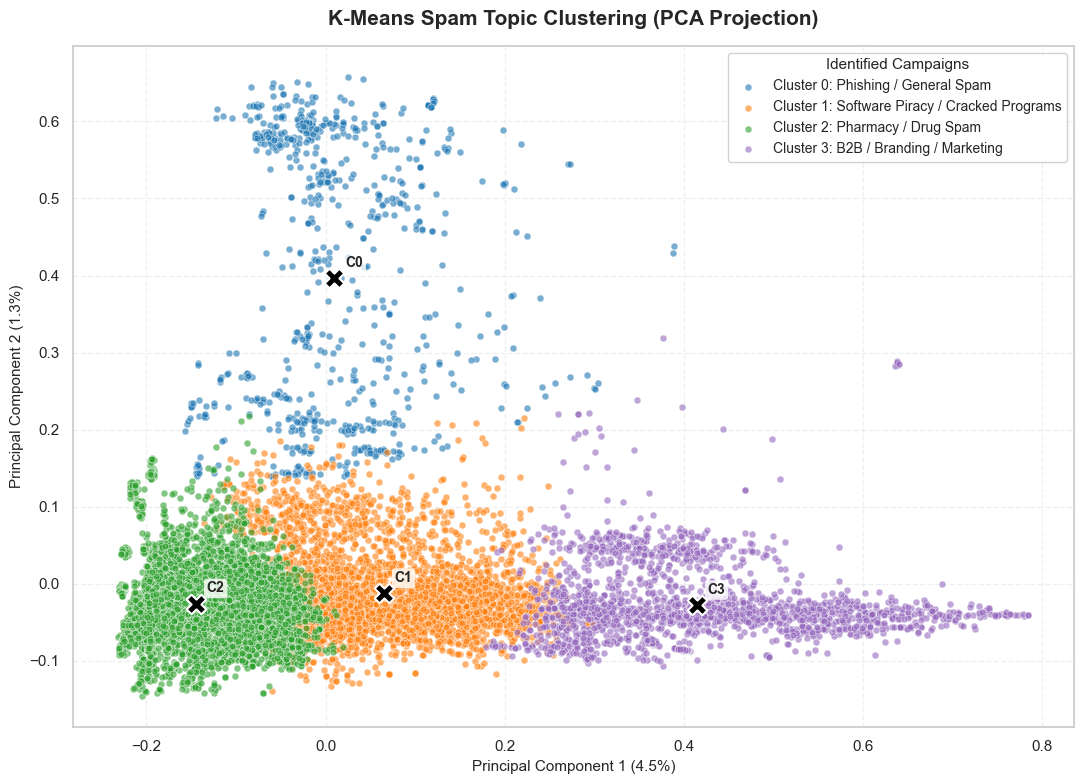

In [14]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from viz_clustering import plot_pca_scatter

# Filter spam only
df_spam = df[df["Spam/Ham"] == "spam"].copy()
df_spam = df_spam[df_spam["cleaned_text"].str.strip() != ""]

# Fit vectorizer strictly on spam
tfidf_spam = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, max_df=0.85, stop_words="english")
X_spam_tfidf = tfidf_spam.fit_transform(df_spam["cleaned_text"])

print("Running K-Means (k=4)...")
km = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
km.fit(X_spam_tfidf)
df_spam["cluster"] = km.labels_

print("K-Means completed. Plotting PCA projection...")
plot_pca_scatter(df_spam, X_spam_tfidf, n_clusters=4)

---
## Section 7: Additional Dataset - NLP Augmentation & Robustness Iteration

Machine Learning models often decay over time as attackers modify their spam templates. 
We generate an **additional synthetic dataset** (`synthetic_nlpaug.csv`) using NLP augmentation (synonyms, typos) to stress-test our models.

In [ ]:
# Note: NLP augmentation takes a long time. For this notebook, we run a small localized sample.
import nlpaug.augmenter.word as naw
import os

gen_file = "synthetic_nlpaug.csv"

if not os.path.exists(gen_file):
    print("Generating synthetic augmented data...")
    # Small test subset
    subset = pd.concat([
        df[df['Spam/Ham'] == 'spam'].sample(500, random_state=42),
        df[df['Spam/Ham'] == 'ham'].sample(500, random_state=42)
    ])
    
    aug_synonym = naw.SynonymAug(aug_src="wordnet", aug_p=0.2)
    
    rows = []
    for _, row in subset.iterrows():
        try:
            msg = str(row['Message']).strip()
            if len(msg) > 10:
                aug_msg = aug_synonym.augment(msg)
                if isinstance(aug_msg, list): aug_msg = aug_msg[0]
                rows.append({'Spam/Ham': row['Spam/Ham'], 'combined_text': aug_msg})
        except:
            pass
            
    df_aug = pd.DataFrame(rows)
    df_aug.to_csv(gen_file, index=False)
    print(f"Generated {len(df_aug)} augmented records and saved to {gen_file}")
else:
    df_aug = pd.read_csv(gen_file)
    print(f"Loaded existing augmented data containing {len(df_aug)} records.")

# Clean augmented text
df_aug["cleaned_text"] = df_aug["combined_text"].apply(clean_text)
y_aug_true = le.transform(df_aug['Spam/Ham'])

# Stress Test using best tuned model
y_aug_pred = tuned_svm.predict(df_aug["cleaned_text"])
print("Robustness Test Accuracy on Synthetic Data:", accuracy_score(y_aug_true, y_aug_pred))

---
## Section 8: Model Saving & Prediction Inference

Exporting the full pipelines for actual application use.

In [ ]:
os.makedirs("saved_models", exist_ok=True)

# Save text pipeline
joblib.dump(tuned_svm, "saved_models/spam_pipeline.pkl", compress=3)
joblib.dump(le, "saved_models/label_encoder.pkl")

# Save metadata pipeline
joblib.dump(meta_pipeline, "saved_models/spam_pipeline_with_metadata.pkl", compress=3)

print("Models securely saved to 'saved_models/' directory.")

# Prediction Function
def predict_spam(text, model=tuned_svm, encoder=le):
    cleaned = clean_text(text)
    pred = model.predict([cleaned])[0]
    label = encoder.inverse_transform([pred])[0]
    
    if hasattr(model, "predict_proba"):
        prob = max(model.predict_proba([cleaned])[0])
        return f"[{label.upper()}] (Conf: {prob:.2%})"
    return f"[{label.upper()}]"

print("Sample Inferences:")
print("1.", predict_spam("URGENT: Your account has been locked. Click here to verify your identity http://fake-bank.com"))
print("2.", predict_spam("Hey man, are we still meeting for lunch at 12? Let me know."))
print("3.", predict_spam("Incredible new crypto investment, guaranteed 500% ROI overnight without risk!"))